In [1]:
# !pip install statsmodels

In [1]:
# pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('/content/PJME_hourly.csv')

df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

df = df.sort_index()

# Remove duplicates
df = df[~df.index.duplicated(keep='first')]

# Set hourly frequency
df = df.asfreq('h')


print(df.head())

                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0


In [4]:
print("---INFO----")
print(df.info())
print("----Describe----")
print(df.describe())
print("-----IsNull----")
print(df.isnull().sum())

---INFO----
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145392 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Freq: h
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145362 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB
None
----Describe----
             PJME_MW
count  145362.000000
mean    32080.510780
std      6463.866507
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000
-----IsNull----
PJME_MW    30
dtype: int64


In [5]:
df['PJME_MW'] = df['PJME_MW'].fillna(df['PJME_MW'].median())

In [6]:
df.isnull().sum()

,0
PJME_MW,0


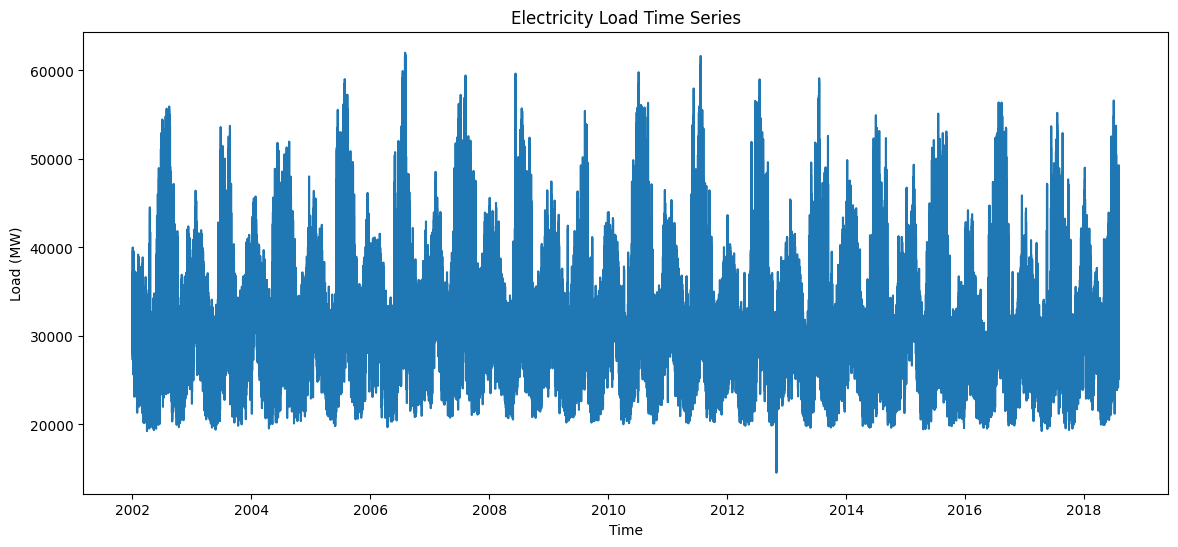

In [7]:
plt.figure(figsize=(14,6))
plt.plot(df['PJME_MW'])
plt.title("Electricity Load Time Series")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.show()

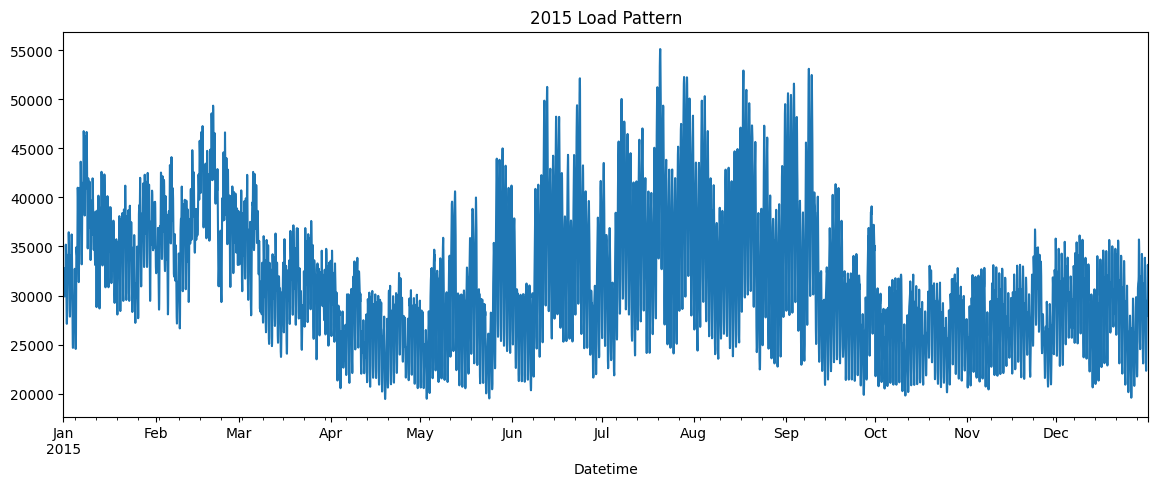

In [8]:
df['PJME_MW'].loc['2015'].plot(figsize=(14,5), title="2015 Load Pattern")
plt.show()

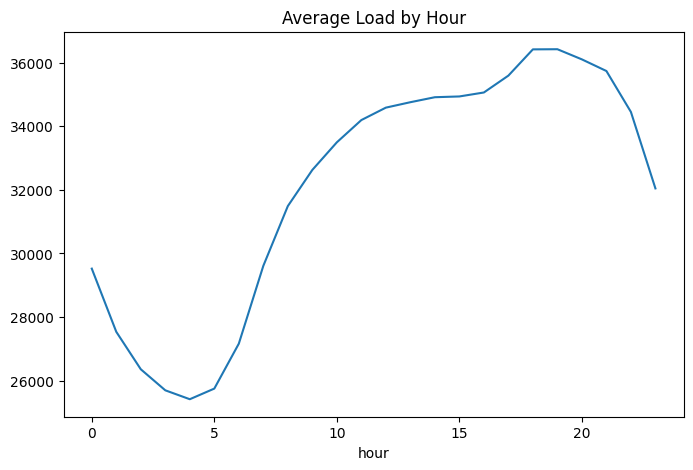

In [9]:
df['hour'] = df.index.hour

hourly_avg = df.groupby('hour')['PJME_MW'].mean()

hourly_avg.plot(figsize=(8,5), title="Average Load by Hour")
plt.show()

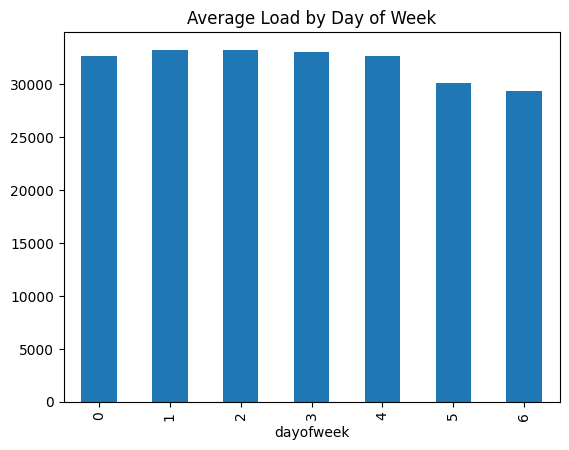

In [10]:
df['dayofweek'] = df.index.dayofweek

weekly_avg = df.groupby('dayofweek')['PJME_MW'].mean()

weekly_avg.plot(kind='bar', title="Average Load by Day of Week")
plt.show()

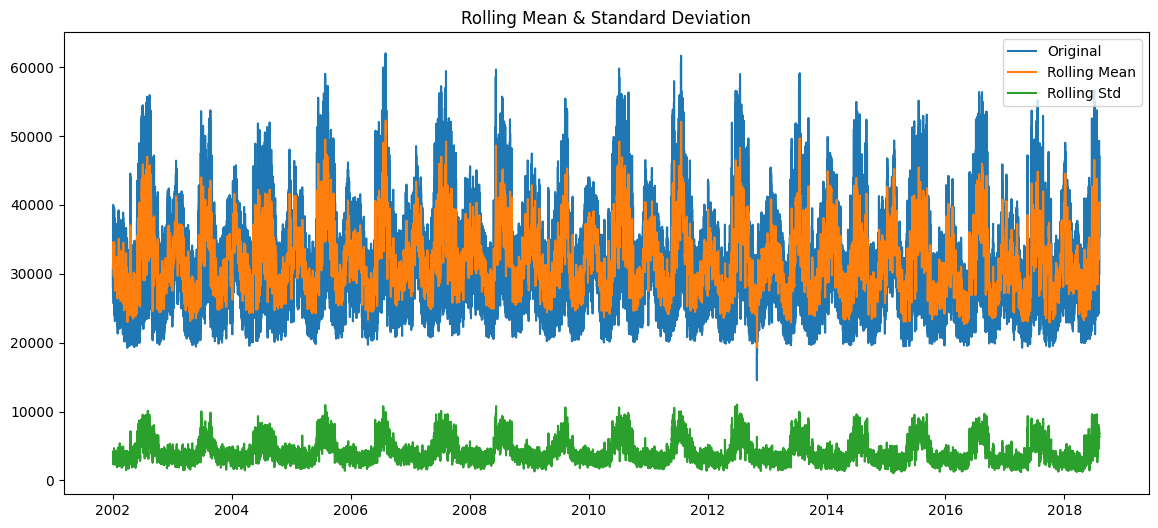

In [11]:
rolling_mean = df['PJME_MW'].rolling(window=24).mean()
rolling_std = df['PJME_MW'].rolling(window=24).std()

plt.figure(figsize=(14,6))
plt.plot(df['PJME_MW'], label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")

plt.legend()
plt.title("Rolling Mean & Standard Deviation")
plt.show()

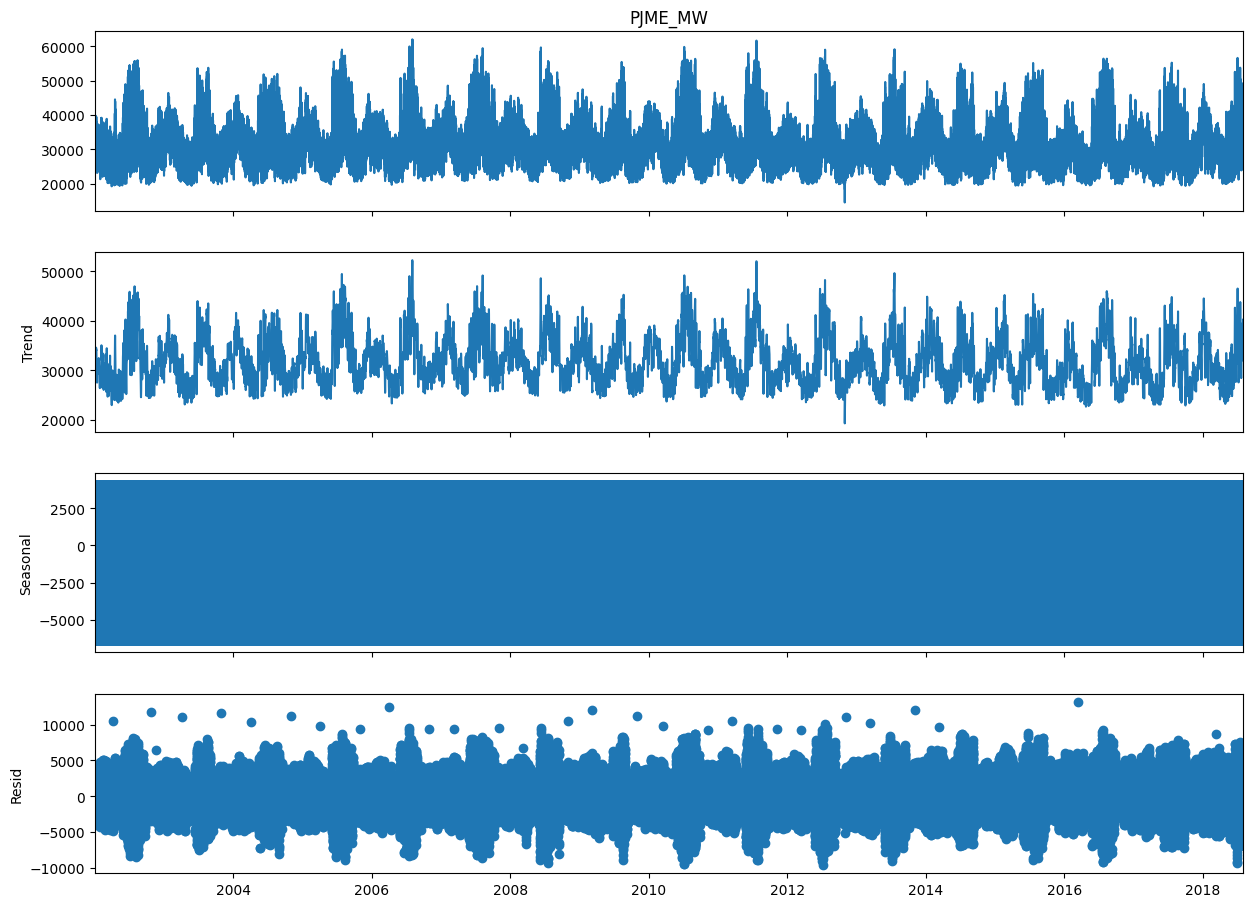

In [25]:
decomposition = seasonal_decompose(df['PJME_MW'], model='additive', period=24)

fig = decomposition.plot()
fig.set_size_inches(14,10)
plt.show()

In [13]:
df['diff'] = df['PJME_MW'].diff()

df_stationary = df['diff'].dropna()

In [14]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [16]:
train_sample = train['PJME_MW'].iloc[-20000:]

In [17]:
model = auto_arima(
    train_sample,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,
    seasonal=False,
    stepwise=True
)

In [18]:
best_order = model.order
print("Best ARIMA order:", best_order)

Best ARIMA order: (3, 1, 3)


In [19]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['PJME_MW'], order=best_order)
model_fit = model.fit()

In [20]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                PJME_MW   No. Observations:               116313
Model:                 ARIMA(3, 1, 3)   Log Likelihood             -932395.158
Date:                Sun, 22 Mar 2026   AIC                        1864804.315
Time:                        08:41:08   BIC                        1864871.963
Sample:                    01-01-2002   HQIC                       1864824.706
                         - 04-09-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.4250      0.003    884.511      0.000       2.420       2.430
ar.L2         -1.9688      0.005   -375.951      0.000      -1.979      -1.959
ar.L3          0.5125      0.003    186.639      0.0

In [21]:
forecast = model_fit.forecast(steps=len(test))

In [22]:
mae = mean_absolute_error(test['PJME_MW'], forecast)
rmse = np.sqrt(mean_squared_error(test['PJME_MW'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4986.0268461709575
RMSE: 6498.279763683863


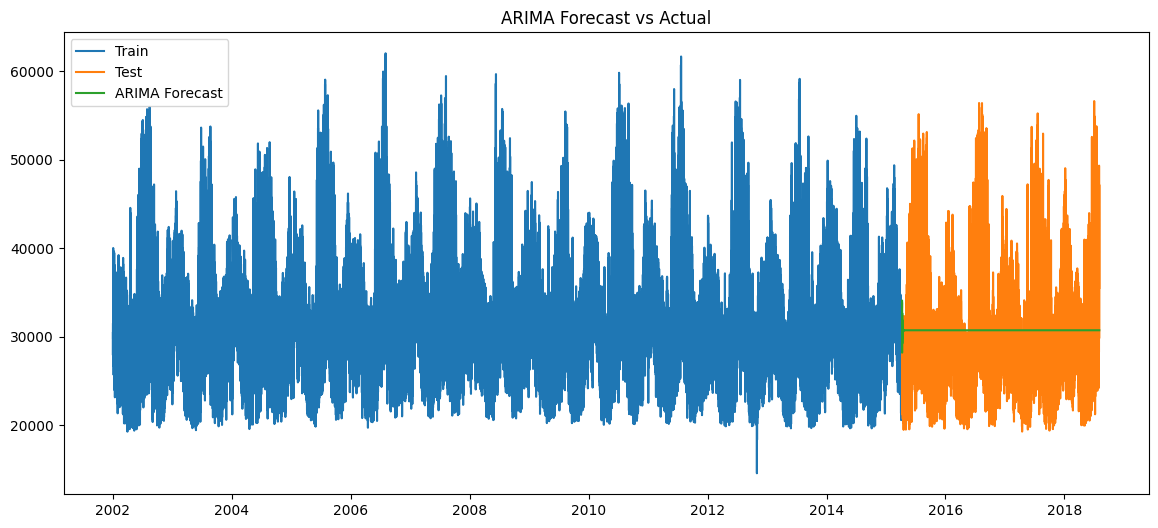

In [23]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train['PJME_MW'], label='Train')
plt.plot(test.index, test['PJME_MW'], label='Test')
plt.plot(test.index, forecast, label='ARIMA Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")

plt.show()